# Comparison of different capabilities of recognizing language in models

1. Training of Models on english literature, german literature, third one?

(https://huggingface.co/datasets/Dorian2B/french-literature-10K)

# Loading english literature

I started with the dataset manu/project_gutenberg which contains all the books on Gutenberg


In [53]:
import random
import re
import torch
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, GenerationConfig


The model gets tested on a number of books from the Gutenberg Project (https://www.gutenberg.org/)
Taken from the dataset manu/project_gutenberg

In [54]:
NUM_TARGET_BOOKS = 100

In [55]:
dataset = load_dataset("manu/project_gutenberg", split="en", streaming=True)

Resolving data files:   0%|          | 0/52 [00:00<?, ?it/s]

This dataset contains an ID and the book. The book part usually has a part that says Title: ___

In [56]:
def parse_metadata(text):
    title = "Unknown Title"
    
    title_match = re.search(r"Title:\s*(.*?)(?=\r?\n\w+:|\r?\n\r?\n)", text, re.IGNORECASE | re.DOTALL)
    if title_match:
        raw_title = title_match.group(1)
        title = re.sub(r'\s+', ' ', raw_title).strip()
        
    return title



In [57]:
def is_a_translation(text):
    translator_match = re.search(r"Translator:\s*(.*)", text, re.IGNORECASE)
    return translator_match is not None

Now the books are fetched and their titles and text saved

In [58]:

books = []
seen_titles = set()
iterator = iter(dataset)

while len(books) < NUM_TARGET_BOOKS:
    try:
        item = next(iterator)
        text = item["text"]
        title = parse_metadata(text)
        
        snippet_start = len(text) // 2
        snippet_end = len(text) // 2 + 1000
        snippet = text[snippet_start:snippet_end].strip()

        title_lower = title.lower()
        # Check that title was not added already (and a title exists)
        if (title != "Unknown Title" 
                and title_lower not in seen_titles and not is_a_translation(text)):
            
            seen_titles.add(title_lower)
            books.append({
                "title": title,
                "text": snippet
            })
            
    except StopIteration:
        print("Error not all books fetched")
        break


Generating multiple choice answers. 

In [59]:
evaluation_set = []
all_titles = [b["title"] for b in books]

for book in books:
    # Generate 3 wrong options
    wrong_choices = [t for t in all_titles if t != book["title"]]
    choices = random.sample(wrong_choices, 3) + [book["title"]]
    random.shuffle(choices)  # Shuffle choices
    
    correct_answer = chr(65 + choices.index(book["title"]))  # A, B, C, or D
    
    evaluation_set.append({
        "snippet": book["text"],
        "choices": choices,
        "correct_letter": correct_answer,
        "correct_title": book["title"]
    })


# Qwen 7b-Model


In [60]:
model_name = "Qwen/Qwen2.5-7B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype="auto",
    device_map="auto" 
)

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

In [61]:
correct_predictions = 0
failed_parses = 0

for i, item in enumerate(evaluation_set):
    prompt_choices = "\n".join([f"{chr(65 + idx)}) {choice}" for idx, choice in enumerate(item["choices"])])
    
    system_prompt = (
        "Your task is to identify which book a provided text snippet belongs to. Respond ONLY with the single letter choice (A, B, C, or D) corresponding to the correct book title. Do not output anything else."
    )
    
    user_prompt = f"\n\"\"\"\n{item['snippet']}\n\"\"\"\n\nWhich book is this snippet from?\n{prompt_choices}\n\nAnswer (A/B/C/D):"
    
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt}
    ]
    text_input = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False
    )
    
    model_inputs = tokenizer([text_input], return_tensors="pt").to(model.device)
    
    with torch.no_grad():
        generated_ids = model.generate(
            **model_inputs,
            max_new_tokens=4,   
            temperature=0.1,
            do_sample=False     
        )

    # Decode only the newly generated tokens
    generated_ids = [
        output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)
    ]
    response = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0].strip().upper()
    
    # Extract letter from answer
    predicted_letter_match = re.search(r'[A-D]', response)
    if predicted_letter_match:
        predicted_letter = predicted_letter_match.group(0)
    else:
        predicted_letter = "Unknown"
        failed_parses += 1
    
    is_correct = (predicted_letter == item["correct_letter"])
    if is_correct:
        correct_predictions += 1

    # Track Accuracy Progress
    if (i + 1) % 10 == 0:
        current_acc = (correct_predictions / (i + 1)) * 100
        print(f"Evaluated {i+1}/{NUM_TARGET_BOOKS} | Running Accuracy: {current_acc:.1f}%")



Evaluated 10/100 | Running Accuracy: 80.0%
Evaluated 20/100 | Running Accuracy: 80.0%
Evaluated 30/100 | Running Accuracy: 83.3%
Evaluated 40/100 | Running Accuracy: 87.5%
Evaluated 50/100 | Running Accuracy: 88.0%
Evaluated 60/100 | Running Accuracy: 86.7%
Evaluated 70/100 | Running Accuracy: 88.6%
Evaluated 80/100 | Running Accuracy: 88.8%
Evaluated 90/100 | Running Accuracy: 87.8%
Evaluated 100/100 | Running Accuracy: 89.0%


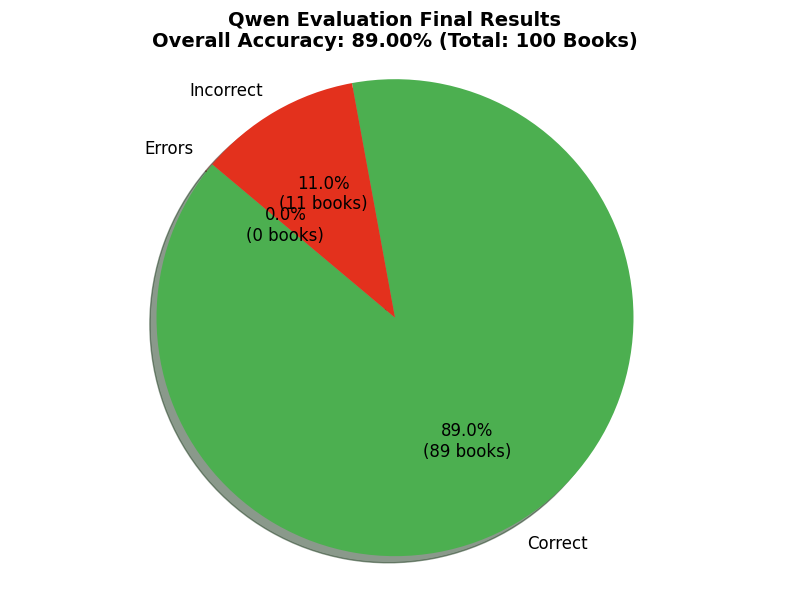

In [62]:
import matplotlib.pyplot as plt

total_questions = len(evaluation_set)
incorrect_predictions = total_questions - correct_predictions - failed_parses

# Data to plot
labels = ['Correct', 'Incorrect', 'Errors']
sizes = [correct_predictions, incorrect_predictions, failed_parses]
colors = ['#4CAF50', "#E3311D", '#FF9800'] 
# explode = (0.1, 0, 0)  

# Create the pie chart
plt.figure(figsize=(8, 6))
plt.pie(
    sizes, 
    # explode=explode, 
    labels=labels, 
    colors=colors,
    autopct=lambda p: '{:.1f}%\n({:.0f} books)'.format(p, p * total_questions / 100),
    shadow=True, 
    startangle=140,
    textprops={'fontsize': 12}
)

# Set title with overall model accuracy
accuracy = (correct_predictions / total_questions) * 100
plt.title(f"Qwen Evaluation Final Results\nOverall Accuracy: {accuracy:.2f}% (Total: {total_questions} Books)", fontsize=14, fontweight='bold')

# Ensure the pie chart is drawn as a circle
plt.axis('equal')  

# Show the plot window
plt.tight_layout()
plt.show()


# Deutsche Übersetzungen


Die benutzte Datenbank besitzt auch ca. 3000 deutschsprachige Bücher, welche wir nun nutzen können, um diese als Übersetzungen zu behandeln. 
Dafür werden zunächst alle Bücher herausgefiltert, welche Übersetzungen vom englischen ins deutsche sind. 

In [65]:
import re
import csv 
from datasets import load_dataset

# 1. Übersetzungsmuster definieren
def is_translation_from_english(text, author=""):
    header_area = text[:4000].lower()
    german_translation_patterns = [
        r"aus\s+dem\s+englischen",
        r"aus\s+d\.\s+englischen",
        r"übersetzung\s+aus\s+dem\s+englischen",
        r"uebersetzung\s+aus\s+dem\s+englischen",
        r"übersetzt\s+aus\s+dem\s+englischen",
        r"uebersetzt\s+aus\s+dem\s+englischen",
        r"übertragen\s+aus\s+dem\s+englischen",
        r"uebertragen\s+aus\s+dem\s+englischen",
        r"vom\s+englischen\s+ins\s+deutsche",
        r"deutsch\s+von.*englischen",
    ]
    
    for pattern in german_translation_patterns:
        if re.search(pattern, header_area):
            return True, "Erkannt via Phrase: 'aus dem Englischen'"
            
    has_translator = "translator:" in header_area or "übersetzer:" in header_area or "uebersetzer:" in header_area
    
    if has_translator and author:
        famous_english_authors = {
            "shakespeare", "dickens", "twain", "poe", "conan doyle", "wilde", "london", "kipling",
            "wells", "austen", "bront", "shelley", "stoker", "carroll", "melville", "hawthorne", 
            "swift", "defoe", "hardy", "thackeray", "alcott", "cooper", "irving", "emerson", "whitman"
        }
        
        author_clean = author.lower()
        for eng_author in famous_english_authors:
            if eng_author in author_clean:
                return True, f"Englischer Autor ({author}) mit Übersetzer-Metadaten."
                
    return False, ""

# 2. Metadaten-Parser
def parse_metadata(text):
    title = "Unknown Title"
    author = "Unknown Author"
    
    title_match = re.search(r"Title:\s*(.*)", text, re.IGNORECASE)
    if title_match:
        title = title_match.group(1).strip()
        title = re.sub(r'[\r\n]', '', title).strip()
        
    author_match = re.search(r"Author:\s*(.*)", text, re.IGNORECASE)
    if author_match:
        author = author_match.group(1).strip()
        author = re.sub(r'[\r\n]', '', author).strip()
        
    return title, author

if __name__ == "__main__":
    print("Lade den deutschen Gutenberg-Datensatz lokal herunter...")
    dataset = load_dataset("manu/project_gutenberg", split="de")
    
    translations = []
    seen_titles = set()
    
    print(f"\nErfolgreich {len(dataset)} deutsche Bücher geladen. Scanne...")
    
    for item in dataset:
        text = item["text"]
        title, author = parse_metadata(text)
        
        normalized_title = re.sub(r'[^\w\s]', '', title).strip().lower()
        matched, reason = is_translation_from_english(text, author)
        
        if matched:
            if normalized_title not in seen_titles and title != "Unknown Title":
                seen_titles.add(normalized_title)
                translations.append({
                    "Deutscher Titel": title,
                    "Autor": author,
                    "Erkennungsgrund": reason,
                    "Originaler Englischer Titel (Manuell)": "" # Hier tragen Sie den englischen Titel ein
                })
                print(f"[MATCHED] {title} von {author}")

    # Als CSV speichern (Semicolon-separiert und mit UTF-8-BOM, damit Excel deutsche Umlaute sofort versteht)
    output_filename = "Gutenberg_Uebersetzungen_Liste.csv"
    
    with open(output_filename, mode="w", encoding="utf-8-sig", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=["Deutscher Titel", "Autor", "Erkennungsgrund", "Originaler Englischer Titel (Manuell)"], delimiter=";")
        writer.writeheader()
        for row in translations:
            writer.writerow(row)
            
    print(f"\nFertig! {len(translations)} Übersetzungen gefunden.")
    print(f"Datei '{output_filename}' wurde erfolgreich erstellt.")

Lade den deutschen Gutenberg-Datensatz lokal herunter...


Resolving data files:   0%|          | 0/52 [00:00<?, ?it/s]


Erfolgreich 3131 deutsche Bücher geladen. Scanne...
[MATCHED] Geschichte von England seit der Thronbesteigung Jakob's des Zweiten. von Thomas Babington Macaulay
[MATCHED] Das Bildnis des Dorian Gray von Oscar Wilde
[MATCHED] Zwei Städte von Charles Dickens
[MATCHED] Gesänge und Inschriften von Walt Whitman
[MATCHED] Jenseits der Schriftkultur - Band 1 von Mihai Nadin
[MATCHED] Ansiedlungen in den Urwäldern von Canada. von Catharine Parr Traill
[MATCHED] Gestalten der Wildnis von Charles G. D. Roberts
[MATCHED] Die Hanse und England von Friedrich Schulz
[MATCHED] Reisebilder von Mark Twain
[MATCHED] Salome von Oscar Wilde
[MATCHED] Der Kaufmann von Venedig von William Shakespeare
[MATCHED] Jenseits der Schriftkultur - Band 2 von Mihai Nadin
[MATCHED] Jenseits der Schriftkultur - Band 3 von Mihai Nadin
[MATCHED] Dhoula Bel von Paschal Beverly Randolph
[MATCHED] Der Weihnachtsabend von Charles Dickens
[MATCHED] Zeugnisse für die Stellung des Menschen in der Natur von Thomas Henry Huxley


1 Buch entfernt, weil englischer Titel nicht auffindbar. 

Am Ende bleiben also 28 einzigartige Übersetzungen von Englischer Literatur. Diese werden nun nach den Titeln abgeglichen.